In [1]:
print("Hola mundo")

Hola mundo


In [61]:
import os
from google.colab import drive

drive.mount("/content/drive")

ruta_zip = '/content/drive/MyDrive/dataset-LZUPSD/Seed dataset.zip'

# 3. Comprobar que el archivo existe en Drive
if os.path.exists(ruta_zip):
    print("✅ Archivo encontrado correctamente en Drive.")
    print(f"Tamaño: {os.path.getsize(ruta_zip) / (1024*1024):.2f} MB")
else:
    print("❌ No se encontró el archivo en la ruta especificada. Verifica el nombre o la carpeta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Archivo encontrado correctamente en Drive.
Tamaño: 66.60 MB


In [62]:
import zipfile
from google.colab import drive

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    # Obtener lista de todos los elementos dentro del ZIP
    lista_contenido = zip_ref.namelist()

    # Extraer y mostrar carpetas principales únicas
    carpetas = set(item.split('/')[0] for item in lista_contenido if '/' in item)

    print("📁 Carpetas principales encontradas dentro del ZIP:")
    for carpeta in sorted(carpetas):
        print(f"  - {carpeta}/")

    print(f"\n📊 Total de archivos contenidos: {len(lista_contenido)}")

📁 Carpetas principales encontradas dentro del ZIP:
  - Seed dataset/

📊 Total de archivos contenidos: 4585



# **1. Inspección inicial de la estructura del dataset**

In [63]:
from pathlib import Path

# Directorio de trabajo actual del entorno
print("Directorio de trabajo:")
print(Path.cwd())

Directorio de trabajo:
/content/bisid-5k-tools


In [65]:
from pathlib import Path

# Sustituir por la ruta real de la carpeta
dataset_dir = Path("/content/drive/MyDrive/dataset-LZUPSD/Seed dataset.zip")

print("¿Existe la carpeta?", dataset_dir.exists())
print("¿Es un directorio?", dataset_dir.is_dir())

¿Existe la carpeta? True
¿Es un directorio? False


In [67]:
import zipfile
import os
from pathlib import Path

# La ruta del ZIP ya está definida en `ruta_zip` de celdas anteriores
# ruta_zip = '/content/drive/MyDrive/dataset-LZUPSD/Seed dataset.zip'

# Directorio donde extraeremos el contenido del ZIP
extraction_path = '/content/Seed_dataset_extracted/'

os.makedirs(extraction_path, exist_ok=True)

print(f"📦 Extrayendo el dataset ZIP de '{ruta_zip}' a '{extraction_path}'...")

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print("✅ Extracción completada.")

# Actualizamos 'dataset_dir' para que apunte a la carpeta extraída
dataset_dir = Path(extraction_path)

print(f"Ahora 'dataset_dir' apunta a: {dataset_dir}")
print("¿Es un directorio ahora?", dataset_dir.is_dir())

📦 Extrayendo el dataset ZIP de '/content/drive/MyDrive/dataset-LZUPSD/Seed dataset.zip' a '/content/Seed_dataset_extracted/'...
✅ Extracción completada.
Ahora 'dataset_dir' apunta a: /content/Seed_dataset_extracted
¿Es un directorio ahora? True


Ahora que el ZIP ha sido extraído y `dataset_dir` apunta a la carpeta correcta, podemos listar su contenido de primer nivel:

In [68]:
from pathlib import Path

# Mostrar los elementos del primer nivel del directorio extraído
if dataset_dir.is_dir():
    print(f"Contenido de '{dataset_dir}':")
    for item in sorted(dataset_dir.iterdir()):
        tipo = "Carpeta" if item.is_dir() else "Archivo"
        print(f"  - {tipo}: {item.name}")
else:
    print(f"❌ ERROR: '{dataset_dir}' no es un directorio. Asegúrate de que la extracción fue exitosa.")

Contenido de '/content/Seed_dataset_extracted':
  - Carpeta: Seed dataset


# **2. Inspección**

In [69]:
from pathlib import Path

# Carpeta que contiene las categorías de semillas
seed_dataset_dir = Path("/content/Seed_dataset_extracted/Seed dataset")

print("📁 Ruta:")
print(seed_dataset_dir)

print("\n¿Existe?:", seed_dataset_dir.exists())
print("¿Es directorio?:", seed_dataset_dir.is_dir())

print("\n📂 Contenido:")
for item in sorted(seed_dataset_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 Carpeta: {item.name}")
    else:
        print(f"  📄 Archivo: {item.name}")

📁 Ruta:
/content/Seed_dataset_extracted/Seed dataset

¿Existe?: True
¿Es directorio?: True

📂 Contenido:
  📁 Carpeta: Achnatherum inebrians
  📁 Carpeta: Achnatherum splendens
  📁 Carpeta: Agriophyllum squarrosum
  📁 Carpeta: Agropyron cristatum
  📁 Carpeta: Agropyron elongatum
  📁 Carpeta: Agropyron mongolicum
  📁 Carpeta: Amorpha fruticosa
  📁 Carpeta: Amygdalus mongolica
  📁 Carpeta: Anemone rivularis
  📁 Carpeta: Apocynum pictum
  📁 Carpeta: Apocynum venetum
  📁 Carpeta: Artemisia desertorum
  📁 Carpeta: Artemisia ordosica
  📁 Carpeta: Artemisia sphaerocephala
  📁 Carpeta: Astragalus laxmannii
  📁 Carpeta: Astragalus melilotoides
  📁 Carpeta: Atriplex sibirica
  📁 Carpeta: Avena sativa
  📁 Carpeta: Bassia dasyphylla
  📁 Carpeta: Bromus inermis
  📁 Carpeta: Buddleja alternifolia
  📁 Carpeta: Calligonum mongolicum Turcz
  📁 Carpeta: Calligonum mongolicum
  📁 Carpeta: Caragana korshinskii
  📁 Carpeta: Caragana liouana
  📁 Carpeta: Caragana microphylla
  📁 Carpeta: Caryopteris mongholic

# **2.2 Identificación de categorías taxonómicas**

In [70]:
# Obtener las categorías a partir de las carpetas
classes = sorted([
    item.name
    for item in seed_dataset_dir.iterdir()
    if item.is_dir()
])

print(f"🌱 Número de categorías encontradas: {len(classes)}")

print("\n📋 Categorías:")
for i, class_name in enumerate(classes, start=1):
    print(f"{i:02d}. {class_name}")

🌱 Número de categorías encontradas: 88

📋 Categorías:
01. Achnatherum inebrians
02. Achnatherum splendens
03. Agriophyllum squarrosum
04. Agropyron cristatum
05. Agropyron elongatum
06. Agropyron mongolicum
07. Amorpha fruticosa
08. Amygdalus mongolica
09. Anemone rivularis
10. Apocynum pictum
11. Apocynum venetum
12. Artemisia desertorum
13. Artemisia ordosica
14. Artemisia sphaerocephala
15. Astragalus laxmannii
16. Astragalus melilotoides
17. Atriplex sibirica
18. Avena sativa
19. Bassia dasyphylla
20. Bromus inermis
21. Buddleja alternifolia
22. Calligonum mongolicum Turcz
23. Calligonum mongolicum
24. Caragana korshinskii
25. Caragana liouana
26. Caragana microphylla
27. Caryopteris mongholica
28. Clematis fruticosa
29. Corethrodendron lignosum
30. Corethrodendron scoparium
31. Corethrodendron fruticosum var. mongolicum
32. Coronilla varia
33. Cosmos bipinnatus
34. Cynanchum acutum
35. Descurainia sophia
36. Elaeagnus angustifolia
37. Elymus nutans
38. Elymus sibiricus
39. Elymus 

# **2.3 Distribución de imágenes por categoría**

In [71]:
from collections import Counter

# Extensiones consideradas como imágenes
image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

# Contar imágenes por categoría
class_counts = {}

for class_name in classes:
    class_dir = seed_dataset_dir / class_name

    count = sum(
        1
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

    class_counts[class_name] = count

# Mostrar resultados
print("📊 Imágenes por categoría:\n")

for i, (class_name, count) in enumerate(class_counts.items(), start=1):
    print(f"{i:02d}. {class_name:<40} → {count} imágenes")

# Estadísticas generales
counts = list(class_counts.values())

print("\n" + "=" * 60)
print("📈 RESUMEN")
print("=" * 60)

print(f"Categorías:       {len(class_counts)}")
print(f"Total imágenes:   {sum(counts)}")
print(f"Mínimo/clase:     {min(counts)}")
print(f"Máximo/clase:     {max(counts)}")
print(f"Promedio/clase:   {sum(counts) / len(counts):.2f}")

📊 Imágenes por categoría:

01. Achnatherum inebrians                    → 42 imágenes
02. Achnatherum splendens                    → 43 imágenes
03. Agriophyllum squarrosum                  → 89 imágenes
04. Agropyron cristatum                      → 56 imágenes
05. Agropyron elongatum                      → 37 imágenes
06. Agropyron mongolicum                     → 47 imágenes
07. Amorpha fruticosa                        → 40 imágenes
08. Amygdalus mongolica                      → 40 imágenes
09. Anemone rivularis                        → 49 imágenes
10. Apocynum pictum                          → 45 imágenes
11. Apocynum venetum                         → 49 imágenes
12. Artemisia desertorum                     → 45 imágenes
13. Artemisia ordosica                       → 49 imágenes
14. Artemisia sphaerocephala                 → 76 imágenes
15. Astragalus laxmannii                     → 37 imágenes
16. Astragalus melilotoides                  → 40 imágenes
17. Atriplex sibirica        

# **3. EDA basico**


## **3. Construcción del inventario de imágenes**

In [72]:
import pandas as pd

# Mapeo reproducible: nombre de especie → identificador numérico
class_to_id = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

records = []

for class_name in classes:
    class_dir = seed_dataset_dir / class_name
    class_id = class_to_id[class_name]

    for file in sorted(class_dir.iterdir()):
        if file.is_file() and file.suffix.lower() in image_extensions:
            records.append({
                "image_path": str(file),
                "class_name": class_name,
                "class_id": class_id
            })

# Crear DataFrame
df_images = pd.DataFrame(records)

print(f"📊 Total de imágenes registradas: {len(df_images):,}")
print(f"🌱 Total de clases: {df_images['class_name'].nunique()}")
print(f"🔢 IDs de clase: {df_images['class_id'].nunique()}")

display(df_images.head(10))

📊 Total de imágenes registradas: 4,496
🌱 Total de clases: 88
🔢 IDs de clase: 88


,image_path,class_name,class_id
0,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
1,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
2,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
3,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
4,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
5,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
6,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
7,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
8,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0
9,/content/Seed_dataset_extracted/Seed dataset/A...,Achnatherum inebrians,0


In [73]:
print("🔎 Comprobaciones")
print("-" * 50)

print("Valores nulos:")
print(df_images.isnull().sum())

print("\nImágenes duplicadas en el inventario:")
print(df_images["image_path"].duplicated().sum())

print("\nIDs de clase:")
print(df_images["class_id"].min(), "→", df_images["class_id"].max())

print("\nDistribución:")
print(df_images["class_name"].value_counts().describe())

🔎 Comprobaciones
--------------------------------------------------
Valores nulos:
image_path    0
class_name    0
class_id      0
dtype: int64

Imágenes duplicadas en el inventario:
0

IDs de clase:
0 → 87

Distribución:
count     88.000000
mean      51.090909
std       13.794582
min       35.000000
25%       45.000000
50%       49.000000
75%       51.000000
max      106.000000
Name: count, dtype: float64


# **3.2 Inspección de formato, dimensiones y canales**

In [74]:
from PIL import Image
from collections import Counter

# Analizar todas las imágenes
image_info = []
corrupted_images = []

for idx, row in df_images.iterrows():
    image_path = Path(row["image_path"])

    try:
        with Image.open(image_path) as img:
            image_info.append({
                "image_path": row["image_path"],
                "class_name": row["class_name"],
                "class_id": row["class_id"],
                "format": img.format,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

    except Exception as e:
        corrupted_images.append({
            "image_path": row["image_path"],
            "error": str(e)
        })

df_image_info = pd.DataFrame(image_info)

print("📊 RESUMEN TÉCNICO")
print("=" * 50)
print(f"Imágenes analizadas:     {len(image_info):,}")
print(f"Imágenes corruptas:      {len(corrupted_images)}")

print("\n📁 Formatos:")
print(df_image_info["format"].value_counts())

print("\n🎨 Modos de color:")
print(df_image_info["mode"].value_counts())

print("\n📐 Dimensiones más frecuentes:")
print(
    df_image_info
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

📊 RESUMEN TÉCNICO
Imágenes analizadas:     4,496
Imágenes corruptas:      0

📁 Formatos:
format
JPEG    4496
Name: count, dtype: int64

🎨 Modos de color:
mode
RGB    4496
Name: count, dtype: int64

📐 Dimensiones más frecuentes:
width  height
192    272       4496
dtype: int64


## **4. Verificación de duplicados visuales**

In [75]:
import hashlib

# Calcular hash MD5 para cada archivo
hash_records = []

for image_path in df_images["image_path"]:
    image_path = Path(image_path)

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_records.append(file_hash)

df_images["file_hash"] = hash_records

# Contar hashes repetidos
duplicate_hashes = (
    df_images["file_hash"]
    .value_counts()
)

duplicate_hashes = duplicate_hashes[
    duplicate_hashes > 1
]

print("🔍 ANÁLISIS DE DUPLICADOS")
print("=" * 50)

print(f"Total de imágenes: {len(df_images):,}")
print(f"Hashes únicos: {df_images['file_hash'].nunique():,}")
print(f"Grupos de duplicados: {len(duplicate_hashes)}")

print(
    f"Imágenes pertenecientes a grupos duplicados: "
    f"{duplicate_hashes.sum() if len(duplicate_hashes) > 0 else 0}"
)

🔍 ANÁLISIS DE DUPLICADOS
Total de imágenes: 4,496
Hashes únicos: 4,494
Grupos de duplicados: 2
Imágenes pertenecientes a grupos duplicados: 4


# **4. Localización de archivos duplicados**

In [76]:
# Obtener los hashes que aparecen más de una vez
duplicated_hashes = (
    df_images["file_hash"]
    .value_counts()
)

duplicated_hashes = duplicated_hashes[
    duplicated_hashes > 1
].index

# Mostrar las imágenes duplicadas
df_duplicates = (
    df_images[df_images["file_hash"].isin(duplicated_hashes)]
    .sort_values("file_hash")
)

print("🔍 ARCHIVOS DUPLICADOS")
print("=" * 80)

display(
    df_duplicates[
        ["image_path", "class_name", "class_id", "file_hash"]
    ]
)

🔍 ARCHIVOS DUPLICADOS


,image_path,class_name,class_id,file_hash
693,/content/Seed_dataset_extracted/Seed dataset/A...,Artemisia sphaerocephala,13,9b8dda01c44b3185f8775aabc6b4a48c
696,/content/Seed_dataset_extracted/Seed dataset/A...,Artemisia sphaerocephala,13,9b8dda01c44b3185f8775aabc6b4a48c
644,/content/Seed_dataset_extracted/Seed dataset/A...,Artemisia sphaerocephala,13,f945197d632d9145b7f285b4cd0336ed
4313,/content/Seed_dataset_extracted/Seed dataset/T...,Trifolium repens,83,f945197d632d9145b7f285b4cd0336ed


In [77]:
print("📊 Categorías involucradas en duplicados:")
print(
    df_duplicates["class_name"]
    .value_counts()
)

print("\n🔗 Distribución de cada grupo de duplicados:")

for file_hash, group in df_duplicates.groupby("file_hash"):
    print("\nHash:", file_hash)
    print(group[["image_path", "class_name"]].to_string(index=False))

📊 Categorías involucradas en duplicados:
class_name
Artemisia sphaerocephala    3
Trifolium repens            1
Name: count, dtype: int64

🔗 Distribución de cada grupo de duplicados:

Hash: 9b8dda01c44b3185f8775aabc6b4a48c
                                                                           image_path               class_name
/content/Seed_dataset_extracted/Seed dataset/Artemisia sphaerocephala/changed2648.jpg Artemisia sphaerocephala
/content/Seed_dataset_extracted/Seed dataset/Artemisia sphaerocephala/changed2651.jpg Artemisia sphaerocephala

Hash: f945197d632d9145b7f285b4cd0336ed
                                                                           image_path               class_name
/content/Seed_dataset_extracted/Seed dataset/Artemisia sphaerocephala/changed2599.jpg Artemisia sphaerocephala
        /content/Seed_dataset_extracted/Seed dataset/Trifolium repens/changed2527.jpg         Trifolium repens


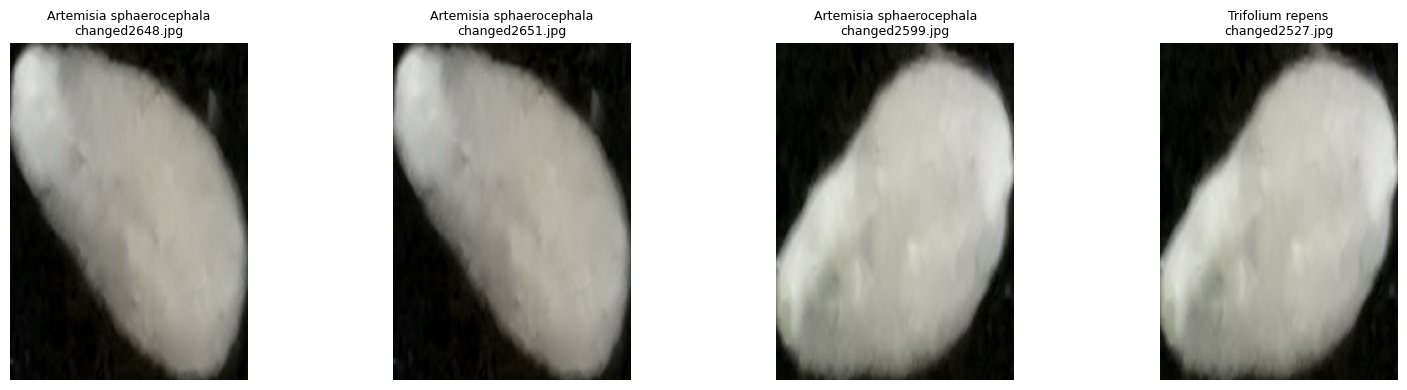

In [78]:
from PIL import Image
import matplotlib.pyplot as plt

# Seleccionar los archivos involucrados en los duplicados
duplicate_paths = df_duplicates["image_path"].tolist()

fig, axes = plt.subplots(
    1,
    len(duplicate_paths),
    figsize=(16, 4)
)

for ax, image_path in zip(axes, duplicate_paths):
    with Image.open(image_path) as img:
        ax.imshow(img)

    ax.set_title(
        Path(image_path).parent.name +
        "\n" +
        Path(image_path).name,
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Hallazgos sobre imágenes duplicadas

El análisis mediante hashes MD5 permitió identificar dos grupos de imágenes duplicadas dentro del conjunto de datos. La inspección visual confirmó que las imágenes pertenecientes a cada grupo son idénticas.

El primer caso corresponde a changed2648.jpg y changed2651.jpg, ambas pertenecientes a la categoría Artemisia sphaerocephala. Al compartir la misma imagen y la misma etiqueta, se considera un duplicado exacto dentro de una misma clase.

El segundo caso corresponde a changed2599.jpg, ubicada en Artemisia sphaerocephala, y changed2527.jpg, ubicada en Trifolium repens. Estas imágenes son idénticas, pero presentan etiquetas de clase diferentes. Por lo tanto, este caso constituye una posible inconsistencia en las etiquetas del conjunto de datos.

Estos hallazgos se conservarán como parte del análisis exploratorio y serán considerados antes de realizar la partición del conjunto de datos, con el objetivo de evitar que imágenes idénticas aparezcan simultáneamente en diferentes subconjuntos y puedan producir fuga de información o afectar la evaluación del modelo.

# **5. EDA (continuación)**

In [84]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Semilla para que la selección sea reproducible
rng = np.random.default_rng(42)

# Seleccionar una imagen aleatoria por categoría
sample_images = []

for class_name in classes:
    class_images = df_images[
        df_images["class_name"] == class_name
    ]["image_path"].tolist()

    selected_image = rng.choice(class_images)

    sample_images.append({
        "class_name": class_name,
        "image_path": selected_image
    })

print(f"Categorías seleccionadas: {len(sample_images)}")

Categorías seleccionadas: 88


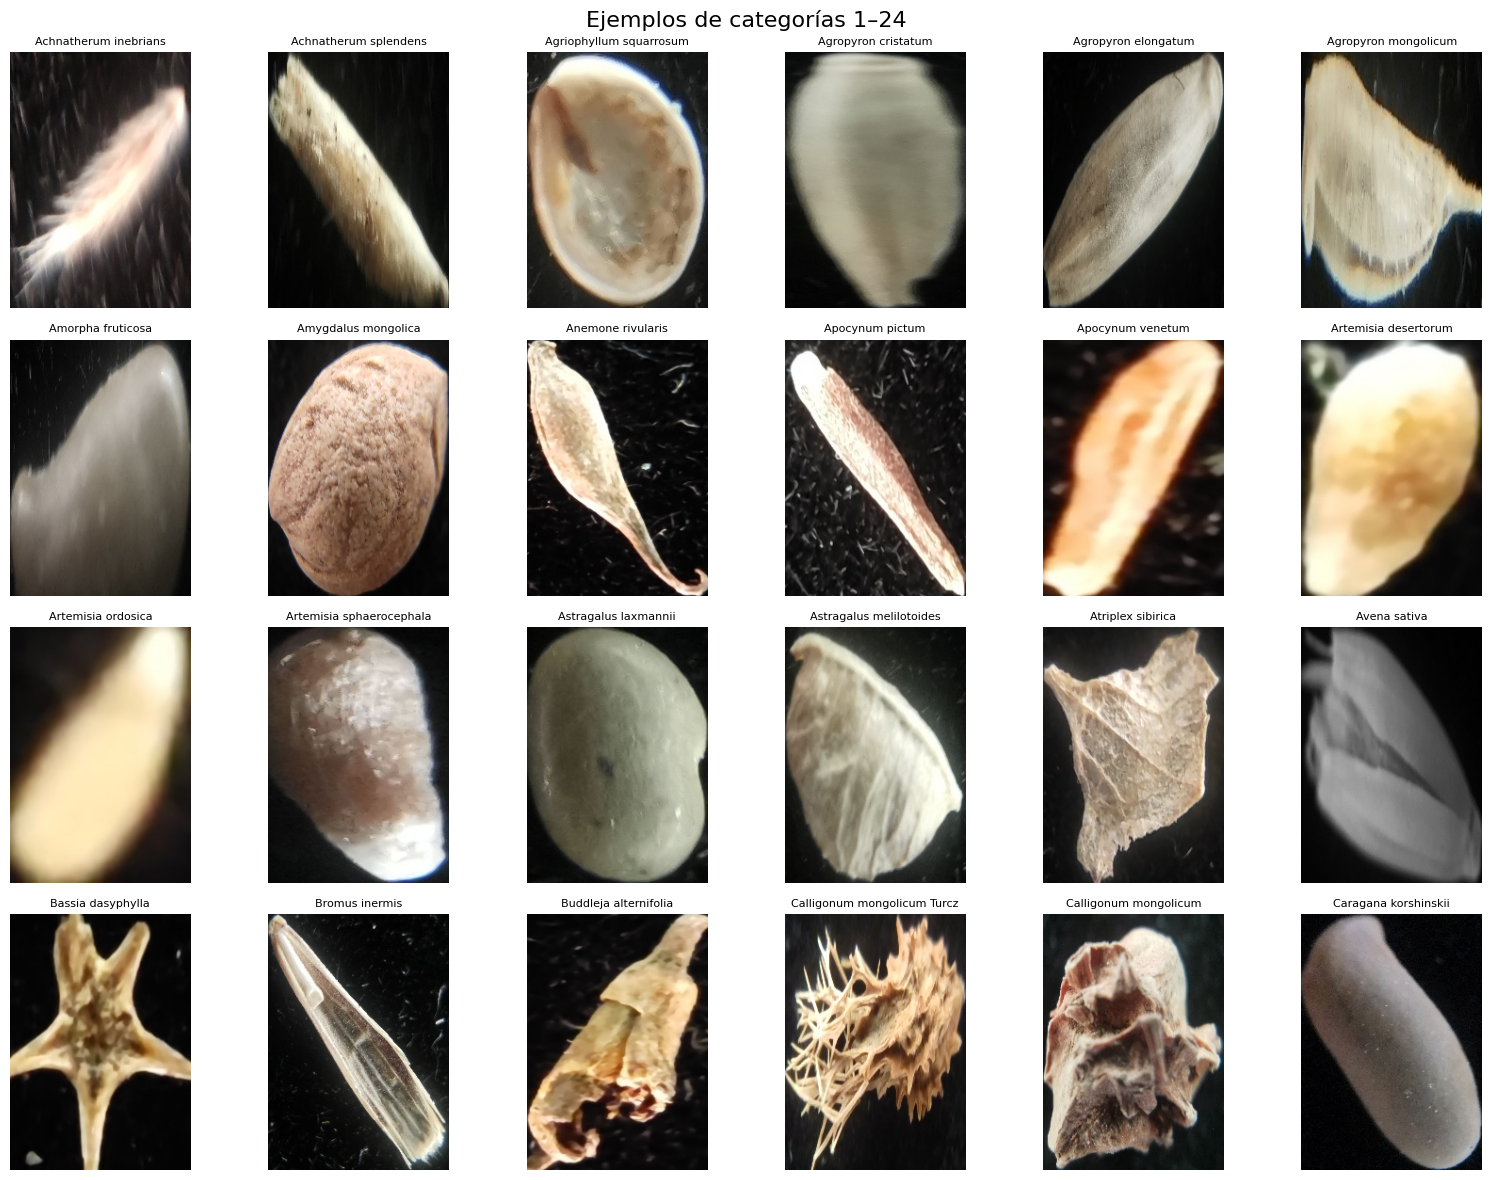

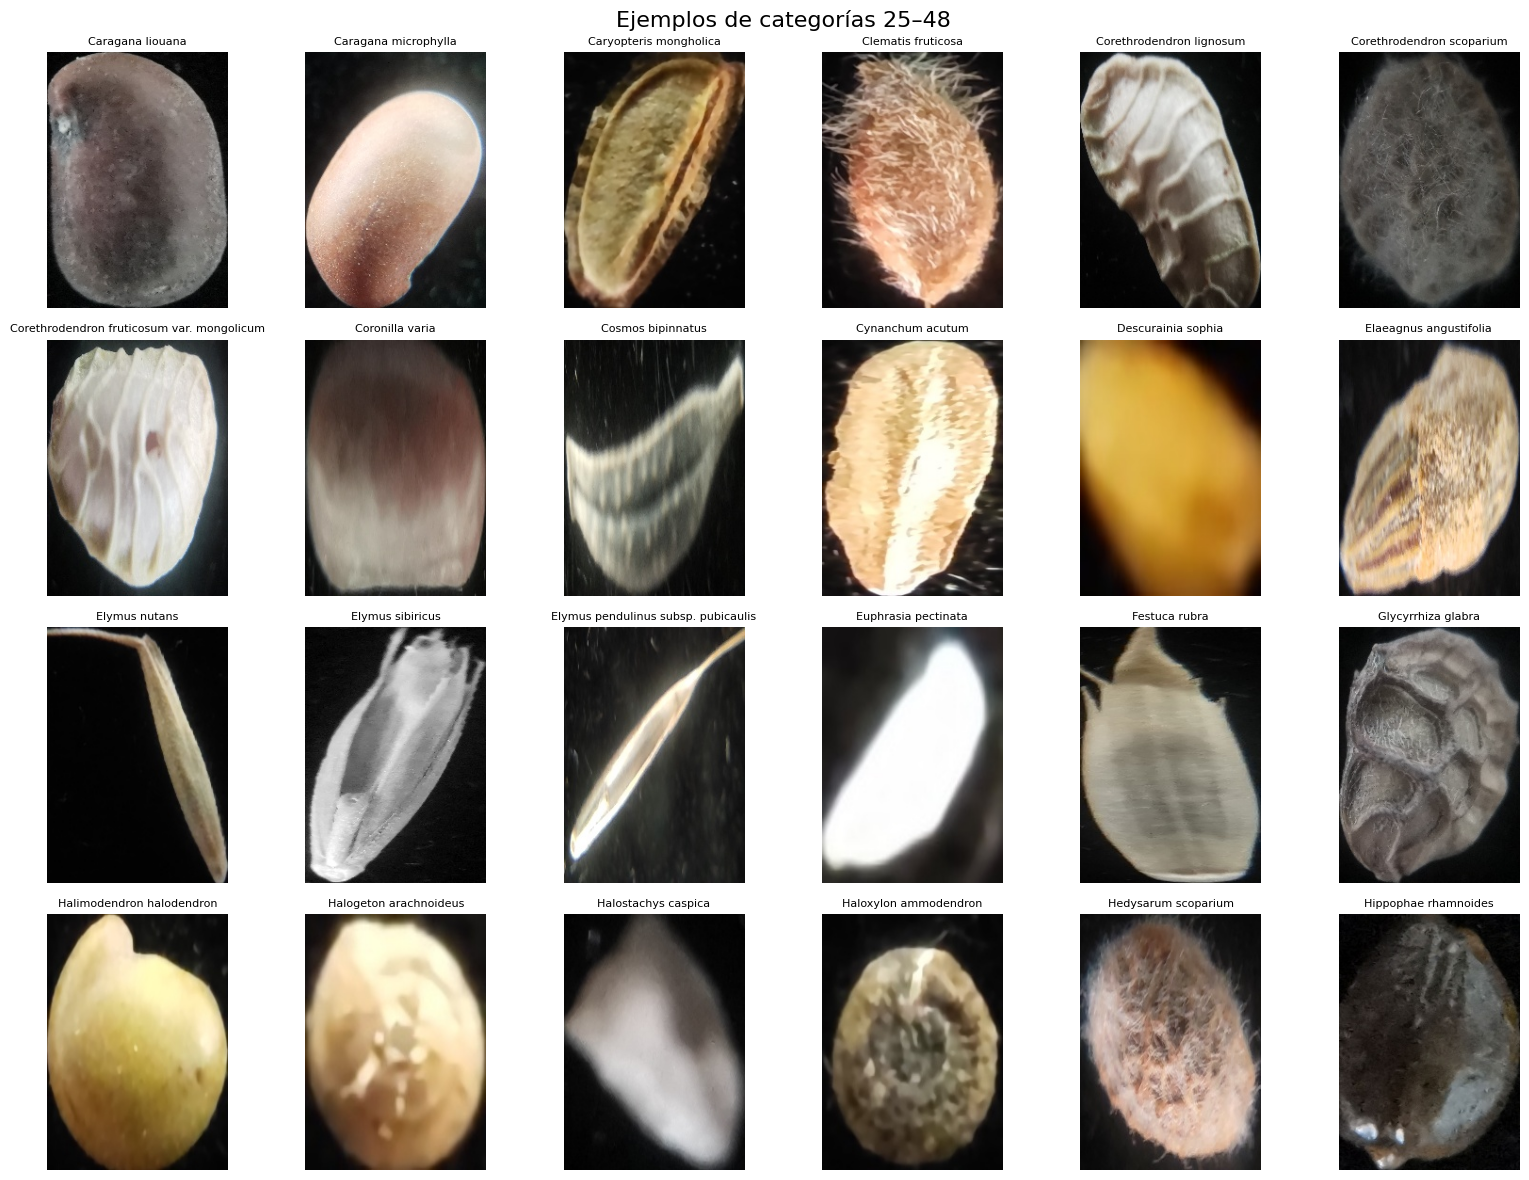

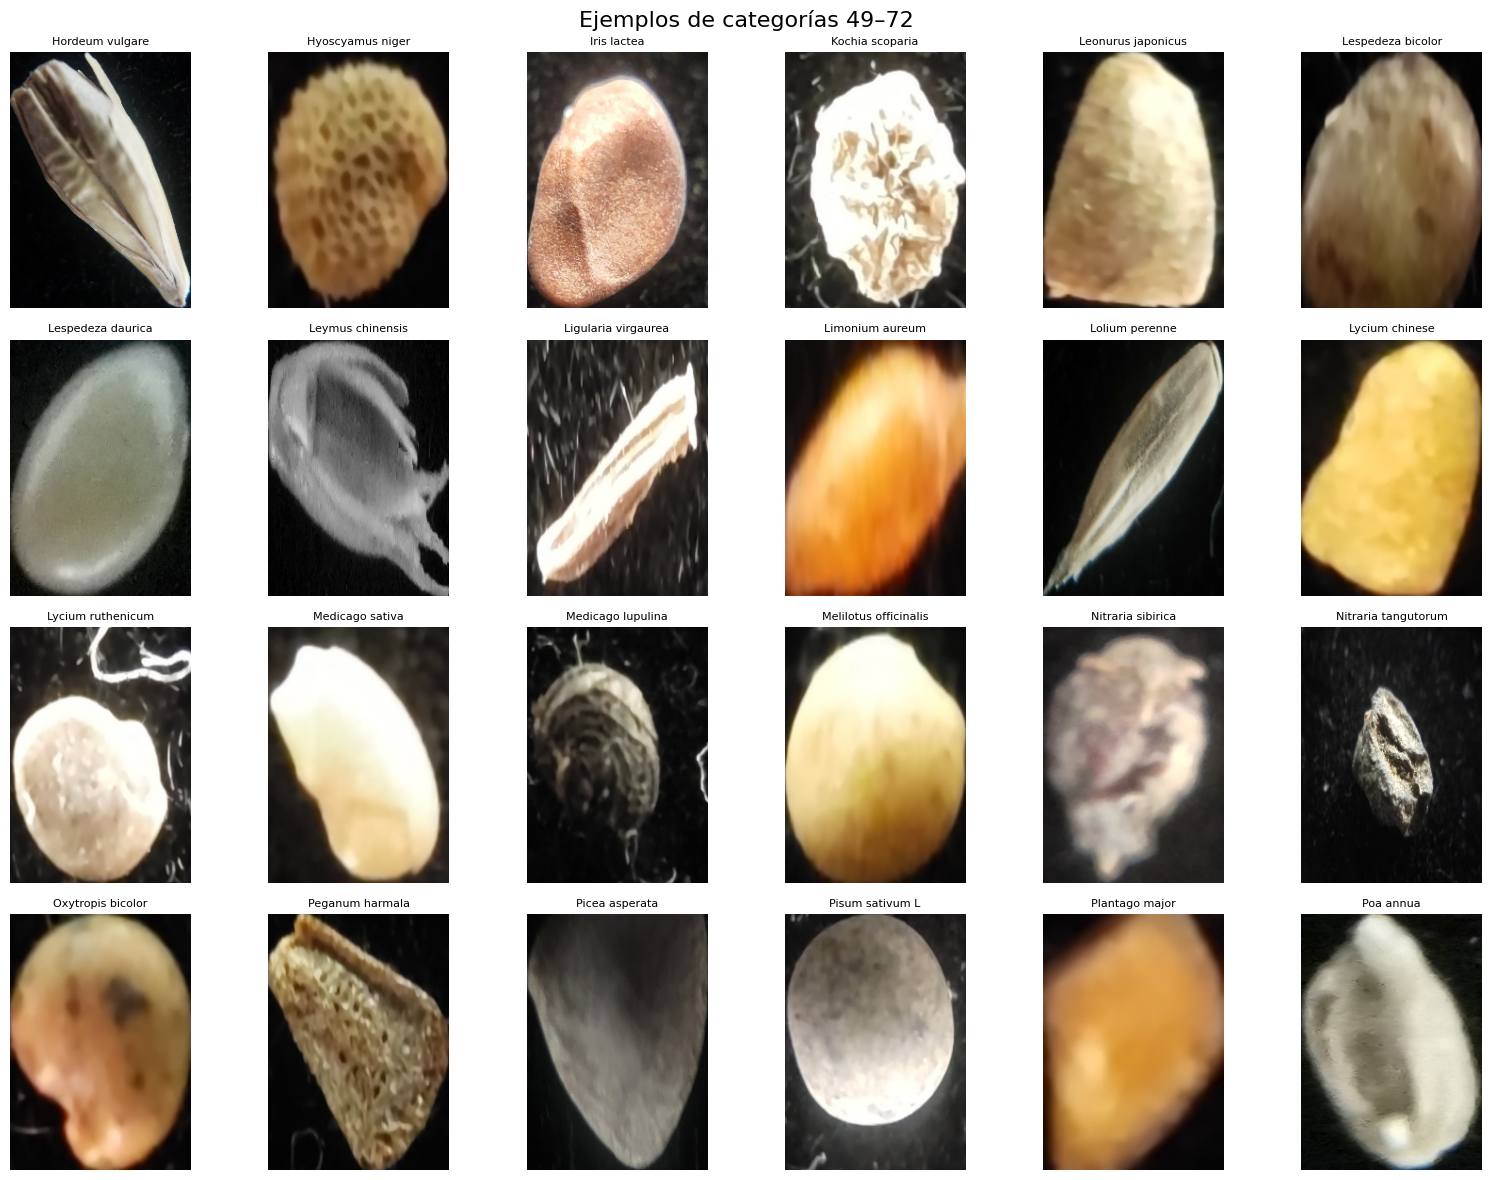

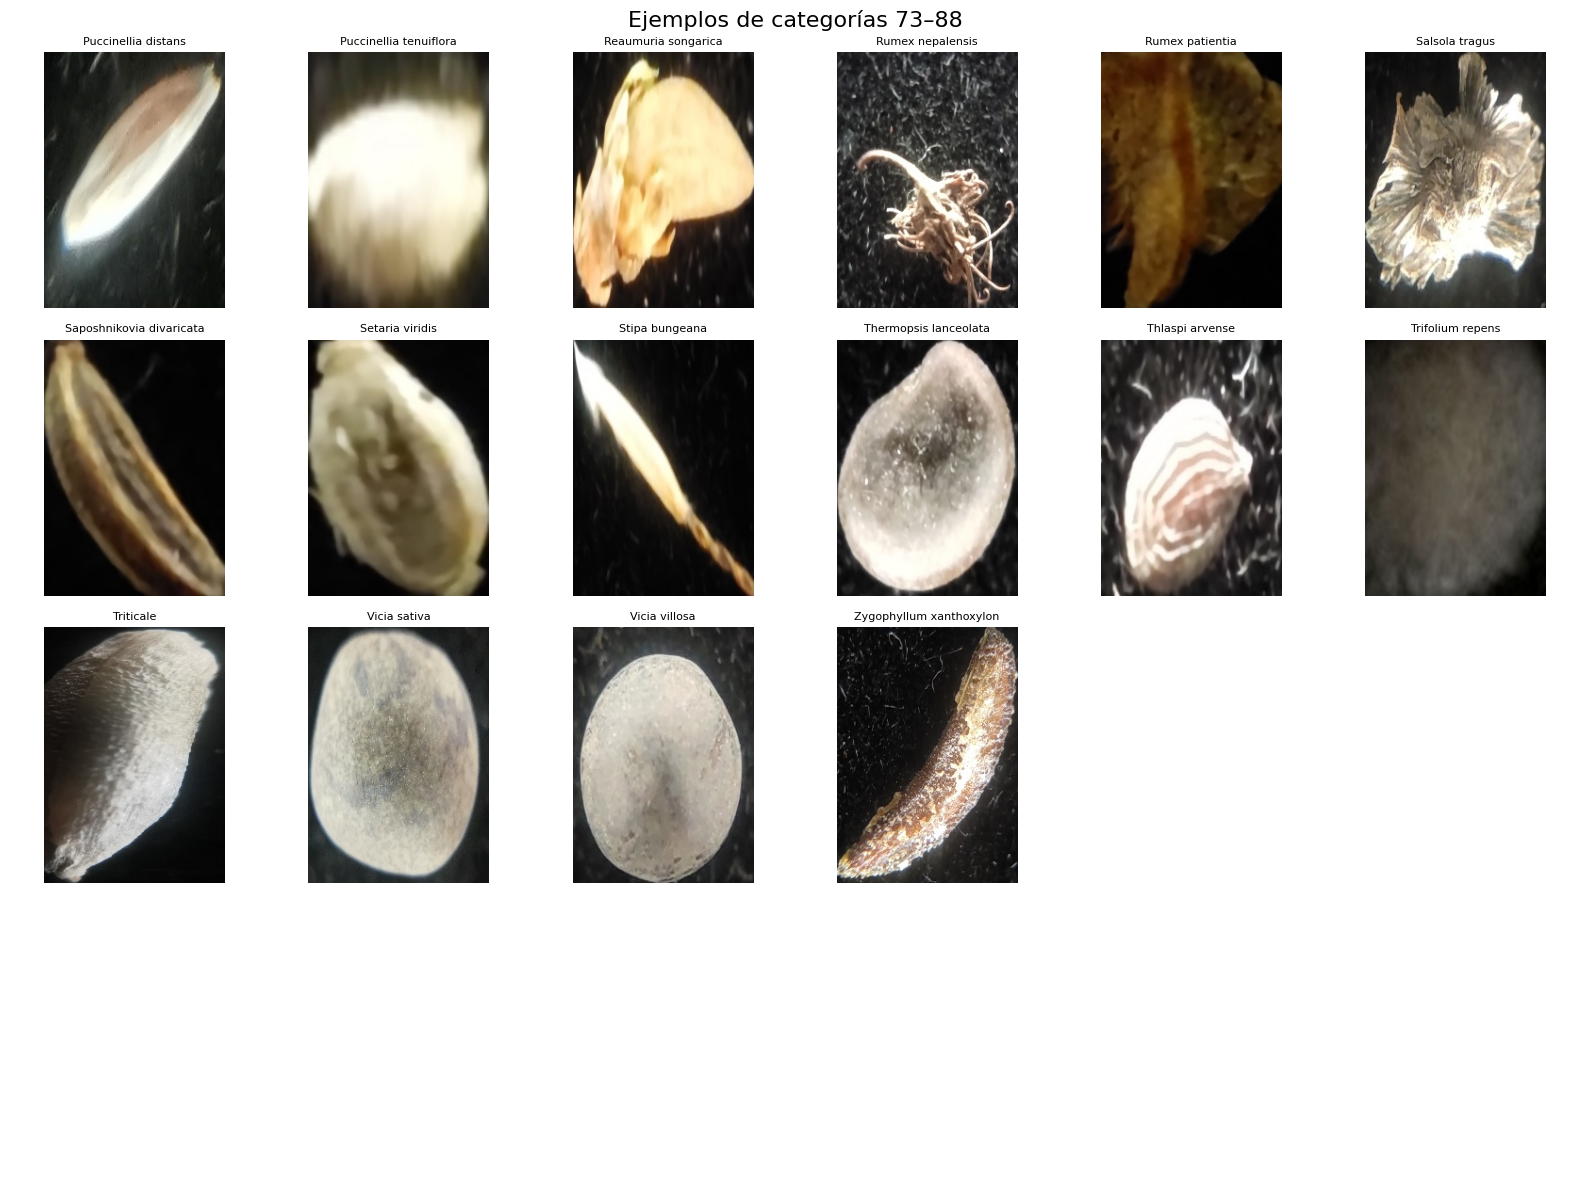

In [85]:
images_per_figure = 24
num_figures = int(np.ceil(len(sample_images) / images_per_figure))

for figure_idx in range(num_figures):

    start = figure_idx * images_per_figure
    end = min(start + images_per_figure, len(sample_images))

    current_samples = sample_images[start:end]

    fig, axes = plt.subplots(
        4,
        6,
        figsize=(16, 12)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, sample in zip(axes, current_samples):

        image_path = sample["image_path"]

        with Image.open(image_path) as img:
            ax.imshow(img)

        ax.set_title(
            sample["class_name"],
            fontsize=8
        )

        ax.axis("off")

    fig.suptitle(
        f"Ejemplos de categorías {start + 1}–{end}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

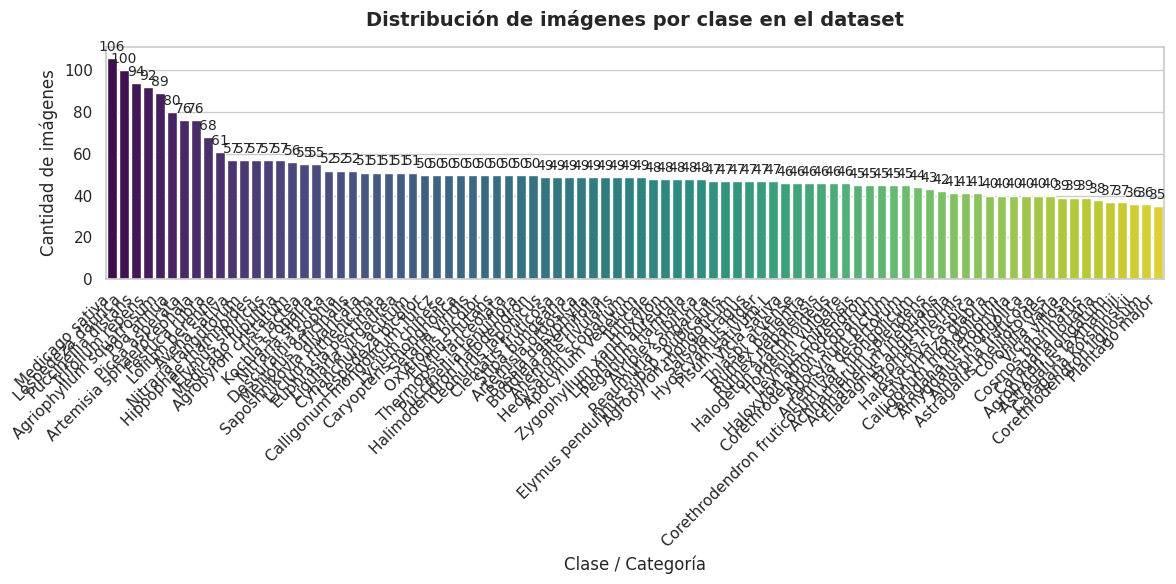

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. Obtener el recuento de imágenes por clase
class_counts = df_images["class_name"].value_counts().reset_index()
class_counts.columns = ["class_name", "count"]

# 3. Crear el gráfico de barras
ax = sns.barplot(
    data=class_counts,
    x="class_name",
    y="count",
    palette="viridis",
    hue="class_name",
    legend=False,
)

# 4. Añadir las etiquetas con el total exacto encima de cada barra
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

# 5. Personalizar títulos y ejes
plt.title(
    "Distribución de imágenes por clase en el dataset",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Clase / Categoría", fontsize=12)
plt.ylabel("Cantidad de imágenes", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotar nombres si son largos

plt.tight_layout()
plt.show()

## **6 Conclusiones del análisis exploratorio**

El análisis exploratorio permitió caracterizar el conjunto de datos LZUPSD utilizado para la identificación taxonómica de semillas. El conjunto contiene **4.496 imágenes distribuidas en 88 categorías**, con una cantidad de imágenes por categoría que varía entre 35 y 106 muestras. Por esta razón, se identificó un cierto desbalance entre las clases, aspecto que deberá considerarse posteriormente mediante una partición estratificada y métricas como el F1 macro.

Desde el punto de vista técnico, todas las imágenes analizadas se encuentran en formato JPEG, presentan tres canales RGB y poseen las mismas dimensiones de **192 × 272 píxeles**. Además, no se encontraron imágenes corruptas durante la inspección.

El análisis de duplicados mediante hashes MD5 identificó dos grupos de imágenes idénticas. Uno corresponde a dos imágenes pertenecientes a la misma categoría, mientras que el segundo corresponde a imágenes idénticas asociadas a categorías diferentes: `Artemisia sphaerocephala` y `Trifolium repens`. Este último caso se considera una posible inconsistencia de etiquetado y deberá ser tratado antes de realizar la partición definitiva del conjunto de datos.

La inspección visual mostró que las categorías presentan diferencias apreciables en la apariencia de las semillas y que existe variabilidad dentro de una misma categoría en aspectos como orientación, escala, iluminación, fondo y composición. Esta variabilidad resulta relevante para evaluar posteriormente la capacidad de BioCLIP para reconocer características visuales asociadas con las categorías y no únicamente patrones particulares de las imágenes.

Con base en estos resultados, el conjunto de datos presenta condiciones adecuadas para continuar con la siguiente etapa del proyecto. Antes del entrenamiento o evaluación del modelo, será necesario establecer el tratamiento de los duplicados e inconsistencias identificadas y realizar una partición reproducible y estratificada de los datos, manteniendo el conjunto de prueba aislado para la evaluación final.
